In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift 
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv('customer_data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


Text(0, 0.5, 'Spending Score (1-100)')

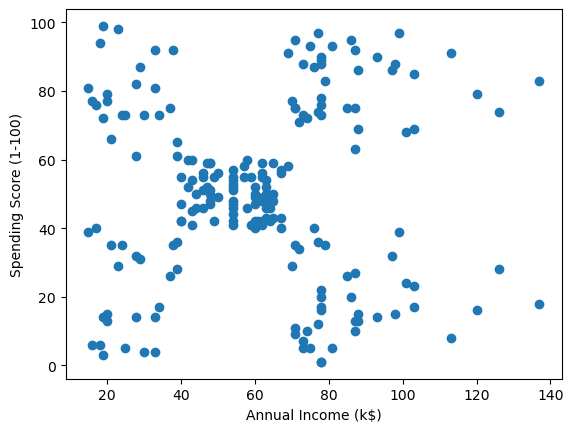

In [3]:
fig, ax = plt.subplots()

ax.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])

ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')

Looking at the visualisation you could make arguments that there are five clusters in the data or that there are 3 clusters. We will start with five clusters.

#### KMeans

In [4]:
X = df.iloc[:,[3,4]].values

kmeans = KMeans(n_clusters = 5, n_init = 'auto', random_state = 42)
kmeans.fit(X)
kmcenters = kmeans.cluster_centers_

ms = MeanShift()
ms.fit(X)
mscenters = ms.cluster_centers_

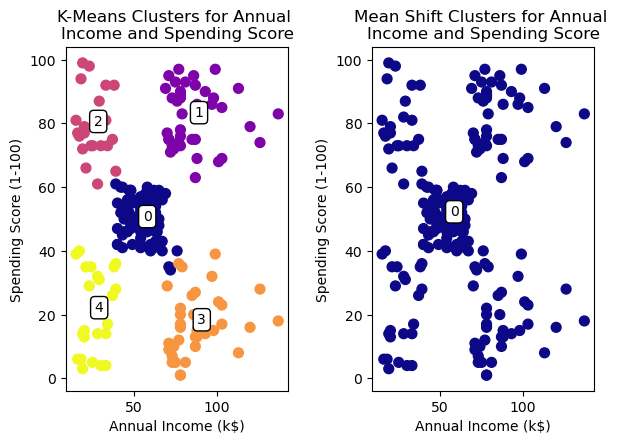

In [5]:
fig, ax = plt.subplots(1,2)

nm1 = Normalize(vmin = 0, vmax = len(kmcenters)-1)

ax[0].scatter(X[:,0], X[:,1], c = kmeans.predict(X[:,[0,1]]), s = 50, cmap = 'plasma', norm = nm1)

for i in range(kmcenters.shape[0]):
    ax[0].text(kmcenters[i,0], kmcenters[i,1], str(i), c = 'black',
            bbox = dict(boxstyle = "round", facecolor = "white", edgecolor = "black"))

ax[0].set_xlabel(df.columns[3])
ax[0].set_ylabel(df.columns[4])
ax[0].set_title('K-Means Clusters for Annual \nIncome and Spending Score')



nm2 = Normalize(vmin = 0, vmax = len(mscenters)-1)

ax[1].scatter(X[:,0], X[:,1], c = ms.predict(X[:,[0,1]]), s = 50, cmap = 'plasma', norm = nm2)

for i in range(mscenters.shape[0]):
    ax[1].text(mscenters[i,0], mscenters[i,1], str(i), c = 'black',
            bbox = dict(boxstyle = "round", facecolor = "white", edgecolor = "black"))

ax[1].set_xlabel(df.columns[3])
ax[1].set_ylabel(df.columns[4])
ax[1].set_title('Mean Shift Clusters for Annual \nIncome and Spending Score')

plt.tight_layout(pad = 2.0)

 - The five clusters identified by the K-Means algorithm correspond to the clusters I recognised when visualising the data. 
 - Cluster 0 represents people with a middling income, 
 - approximatley $40k - $60k, who also have a middling spending score, 40 - 60. 
 - 
 - Cluster 1 and 2 both represent people with a high spending score. 
 - Interestingly, they are disparate in their income. 

 - Cluster 2 being low income, high spending scores. 
 - Cluster 1 being high income, high spending score. 
 - 
 - Then we see a similar pair of clusters for low spending scores in clusters 3 and 4. 
 - Cluster 3 being high income, low spending score. 
 - Cluster 4 being low income, low spending score. 
 - 
 - An argument could be made that we should apply K-Means with three clusters, aiming to combine clusters 1 and 2, 
 - and, clusters 3 and 4. 
 - 
 - Then we would have three clusters: low spending score, 
 - medium spending score, high spending score. However, 
 - if we are aiming to target advertisments to maximise sales. 
 - 
 - I would recommend cluster 1 as the highest priority to target advertisments followed by cluster 2. 
 - Whilst both clusters have similar spending scores, the higher income of those in cluster 1 
 - suggests that these people could buy higher priced items that those in cluster 2 do not.
 - 
 - The Mean Shift algorithm has identified a single cluster. 
 - This is not useful for our current purposes. One thing that we could try is introducing more features to see 
 - if the algorithm identifies more clusters. 
 - For now since we want to focus only on these two features, we will need to experiment with the bandwidth.

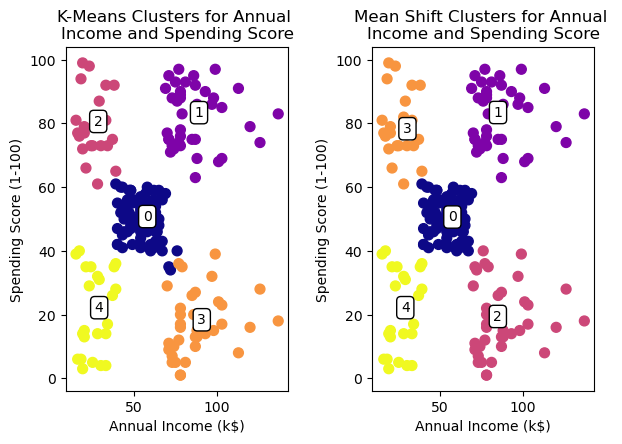

In [6]:
X = df.iloc[:,[3,4]].values

kmeans = KMeans(n_clusters = 5, n_init = 'auto', random_state = 42)
kmeans.fit(X)
kmcenters = kmeans.cluster_centers_

ms = MeanShift(bandwidth = 25)
ms.fit(X)
mscenters = ms.cluster_centers_

fig, ax = plt.subplots(1,2)

nm1 = Normalize(vmin = 0, vmax = len(kmcenters)-1)

ax[0].scatter(X[:,0], X[:,1], c = kmeans.predict(X[:,[0,1]]), s = 50, cmap = 'plasma', norm = nm1)

for i in range(kmcenters.shape[0]):
    ax[0].text(kmcenters[i,0], kmcenters[i,1], str(i), c = 'black',
            bbox = dict(boxstyle = "round", facecolor = "white", edgecolor = "black"))

ax[0].set_xlabel(df.columns[3])
ax[0].set_ylabel(df.columns[4])
ax[0].set_title('K-Means Clusters for Annual \nIncome and Spending Score')

nm2 = Normalize(vmin = 0, vmax = len(mscenters)-1)

ax[1].scatter(X[:,0], X[:,1], c = ms.predict(X[:,[0,1]]), s = 50, cmap = 'plasma', norm = nm2)

for i in range(mscenters.shape[0]):
    ax[1].text(mscenters[i,0], mscenters[i,1], str(i), c = 'black',
            bbox = dict(boxstyle = "round", facecolor = "white", edgecolor = "black"))

ax[1].set_xlabel(df.columns[3])
ax[1].set_ylabel(df.columns[4])
ax[1].set_title('Mean Shift Clusters for Annual \nIncome and Spending Score')

plt.tight_layout(pad = 2.0)

- Manually setting the bandwidth to 25 has resulted in almost identical clusters to the K-Means algorithm with five clusters. 
- Remember, bandwidth is related to the distance between points before the algorithm considers them part of the same cluster.

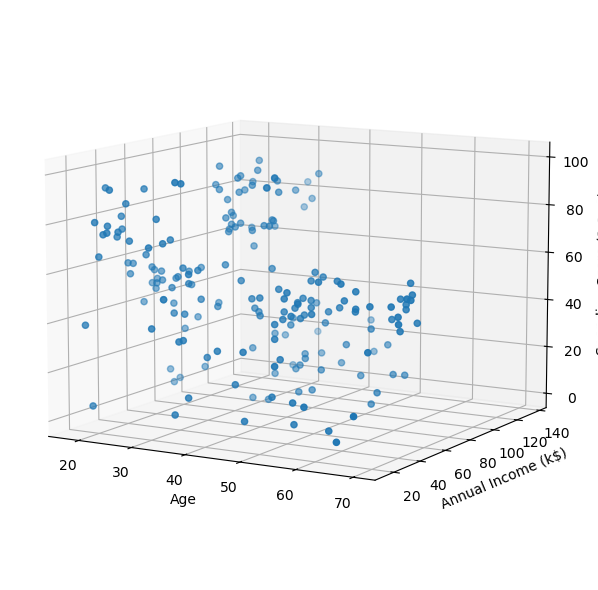

In [7]:
X = df.iloc[:, [2,3,4]].values

fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111, projection = '3d')

scatter = ax.scatter(X[:,0], X[:,1], X[:,2])

ax.azim = -60
ax.dist = 10
ax.elev = 10

ax.set_xlabel(df.columns[2])
ax.set_ylabel(df.columns[3])
ax.set_zlabel(df.columns[4])

fig.tight_layout()

- It is more challenging to identify the number of clusters, k, that we should use from this 3D plot. 
- We could continue with the five that we identified previously when only looking at two features. 
- You can also experiment with the azim, dist and elev values to examine the plot from different angles. 
- For our purposes here lets use five clusters.

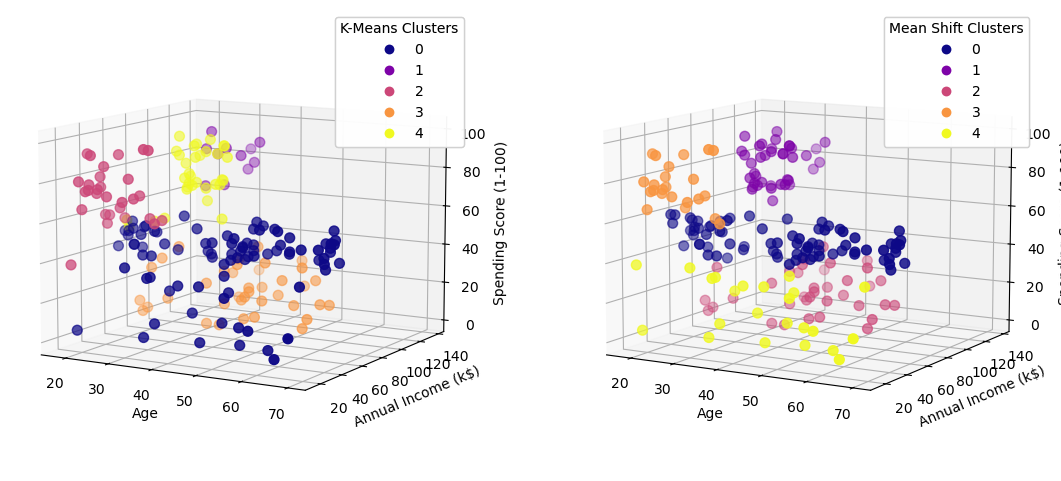

In [12]:
X = df.iloc[:, [2,3,4]].values

kmeans = KMeans(n_clusters = 5, n_init = 'auto', random_state = 42)
kmeans.fit(X[:,[0,1,2]])

kmcenters = kmeans.cluster_centers_

ms = MeanShift(bandwidth = 25)
ms.fit(X)
mscenters = ms.cluster_centers_

fig = plt.figure(figsize =(12,6))

ax1 = fig.add_subplot(121, projection='3d') 
ax2 = fig.add_subplot(122, projection = '3d')

nm1 = Normalize(vmin = 0, vmax = len(kmcenters)-1)
nm2 = Normalize(vmin = 0, vmax = len(mscenters)-1)

scatter1 = ax1.scatter(X[:,0], X[:,1], X[:,2], 
                       c = kmeans.predict(X[:,[0,1,2]]), s = 50, cmap = 'plasma', norm = nm1)


ax1.azim = -60
ax1.dist = 10
ax1.elev = 10

ax1.set_xlabel(df.columns[2])
ax1.set_ylabel(df.columns[3])
ax1.set_zlabel(df.columns[4])

legend1 = ax1.legend(*scatter1.legend_elements(), loc = "best", title = "K-Means Clusters")
ax1.add_artist(legend1)

scatter2 = ax2.scatter(X[:,0], X[:,1], X[:,2], 
                       c = ms.predict(X[:,[0,1,2]]), s = 50, cmap = 'plasma', norm = nm2)

ax2.azim = -60
ax2.dist = 10
ax2.elev = 10

ax2.set_xlabel(df.columns[2])
ax2.set_ylabel(df.columns[3])
ax2.set_zlabel(df.columns[4])

legend2 = ax2.legend(*scatter2.legend_elements(), loc = "best", title = "Mean Shift Clusters")
ax2.add_artist(legend2)

fig.tight_layout(pad = 5.0)

- We can see that the two algorithms deterimened different clusters (after forcing Mean Shift to find five clusters by adjusting bandwidth). 

- I would encourage you to remove the random state and see how the reult for K-Means changes. Change the roatation of the Mean Shift plot to ax2.azim = 180. What do you notice?

- What we begin to see from our visualisations is that a person being under 40 seems related to them having a higher spending score. We could further investigate this by only using Age and Spending Score as our features.